In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [4]:
## Baseline Random Policy - No Training
# Single long run with random action selection
np.random.seed(42)
num_steps = 100000
current_state = 3  # Start at middle state

future_states = [current_state]
pregrets = []

print(f"Starting random policy baseline run for {num_steps} steps...")

for t in range(num_steps):
    # Get valid candidates for current state
    candidates = get_candidates(current_state, t)

    # Randomly select next state from candidates
    next_state = np.random.choice(candidates)
    future_states.append(next_state)
    current_state = next_state

    # Calculate pregret every 100 steps for monitoring
    if (t + 1) % 100 == 0:
        start_idx = t - 99  # Look at last 100 steps
        trajectory_segment = future_states[start_idx:t+2]  # +2 because we need initial state too

        irewards_test = [reward_simulate(trajectory_segment[i], start_idx+i, rewards_in_period)
                        for i in range(1, len(trajectory_segment))]
        preward = compute_normalized_future_rewards(irewards_test, 100, 0.5, normalization=True)

        path, ireward_opt = path_opt(trajectory_segment[0], start_idx, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, 0.5, normalization=True)
        pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100
        pregrets.append(pregret)

        if (t + 1) % 10000 == 0:
            print(f"Step {t+1}/{num_steps}, Recent pregret: {pregret:.4f}, Mean pregret so far: {np.mean(pregrets):.4f}")

print(f"Run complete! Total steps: {len(future_states)-1}")
print(f"Mean pregret over all 100-step windows: {np.mean(pregrets):.4f}")
print(f"Std pregret: {np.std(pregrets):.4f}")

# Save results
np.savez(
    f"../results/PVAFM/baseline_random_policy_{num_steps}steps.npz",
    future_states=np.array(future_states),
    pregrets=np.array(pregrets)
)

Starting random policy baseline run for 100000 steps...
Step 10000/100000, Recent pregret: 2.0102, Mean pregret so far: 2.0230
Step 20000/100000, Recent pregret: 2.0846, Mean pregret so far: 2.0036
Step 30000/100000, Recent pregret: 1.8696, Mean pregret so far: 2.0030
Step 40000/100000, Recent pregret: 2.0956, Mean pregret so far: 2.0034
Step 50000/100000, Recent pregret: 1.7801, Mean pregret so far: 1.9978
Step 60000/100000, Recent pregret: 2.0862, Mean pregret so far: 1.9948
Step 70000/100000, Recent pregret: 2.1235, Mean pregret so far: 1.9973
Step 80000/100000, Recent pregret: 1.9524, Mean pregret so far: 1.9955
Step 90000/100000, Recent pregret: 1.9184, Mean pregret so far: 1.9980
Step 100000/100000, Recent pregret: 1.8847, Mean pregret so far: 1.9986
Run complete! Total steps: 100000
Mean pregret over all 100-step windows: 1.9986
Std pregret: 0.1531


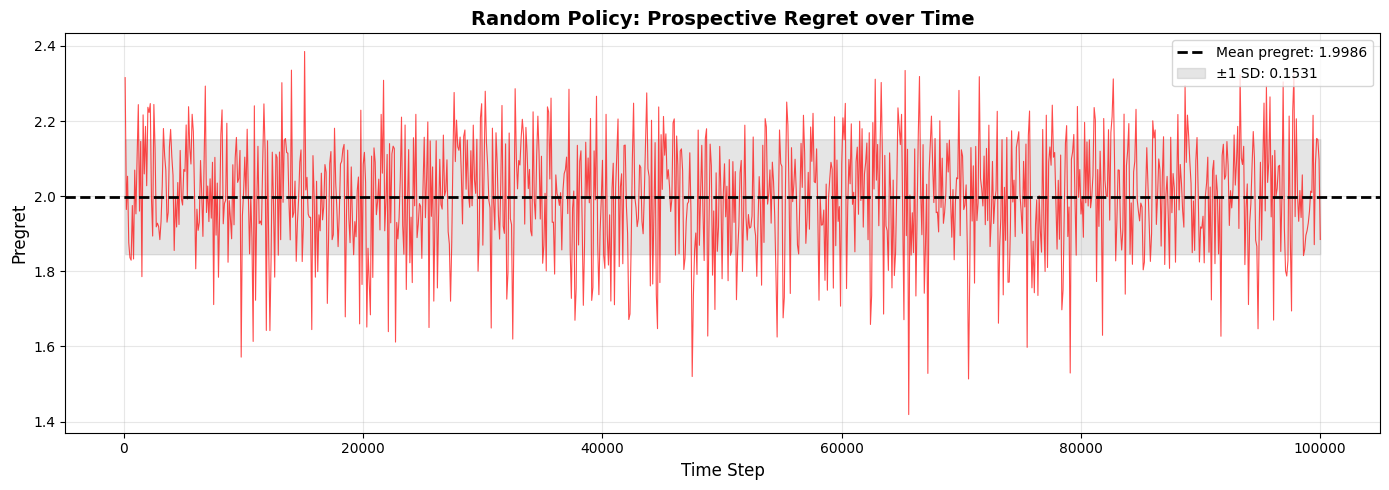

Summary Statistics:
  Total steps: 100000
  Mean pregret: 1.9986
  Std pregret: 0.1531
  Min pregret: 1.4186
  Max pregret: 2.3852


In [9]:
## Plot Baseline Results
# Load the saved baseline data
data = np.load("../results/PVAFM/baseline_random_policy_100000steps.npz")
future_states_baseline = data['future_states']
pregrets_baseline = data['pregrets']

# Create figure with single plot
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Plot pregret over time
time_points = np.arange(100, len(future_states_baseline), 100)  # Every 100 steps
ax.plot(time_points, pregrets_baseline, alpha=0.7, linewidth=0.8, color='red')
ax.axhline(y=np.mean(pregrets_baseline), color='black', linestyle='--', 
            linewidth=2, label=f'Mean pregret: {np.mean(pregrets_baseline):.4f}')
ax.fill_between(time_points, 
                  np.mean(pregrets_baseline) - np.std(pregrets_baseline),
                  np.mean(pregrets_baseline) + np.std(pregrets_baseline),
                  alpha=0.2, color='gray', label=f'±1 SD: {np.std(pregrets_baseline):.4f}')
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Pregret', fontsize=12)
ax.set_title('Random Policy: Prospective Regret over Time', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/PVAFM/baseline_random_policy_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Summary Statistics:")
print(f"  Total steps: {len(future_states_baseline)-1}")
print(f"  Mean pregret: {np.mean(pregrets_baseline):.4f}")
print(f"  Std pregret: {np.std(pregrets_baseline):.4f}")
print(f"  Min pregret: {np.min(pregrets_baseline):.4f}")
print(f"  Max pregret: {np.max(pregrets_baseline):.4f}")